## Morphological Operators

In [1]:
import unist
import scanpy as sc

The datasets used for this tutorial is the reconstruction of human metastatic lymph node and can be downloaded at:

https://drive.google.com/file/d/1FtQ-yUSH418SYTPFRgR-ONolvwmYXgJh/view?usp=sharing

In [2]:
## read in data
adata = sc.read("/Users/shuilan/Library/CloudStorage/OneDrive-InsideMDAnderson/3D spatial transcriptomics/data/3D/OpenST_predicted.h5ad")
adata

AnnData object with n_obs × n_vars = 831406 × 0
    obs: 'pred_label'
    obsm: 'spatial'

In [3]:
from unist.downstream.vis import points_to_imagedata, expression_to_imagedata, three_d_plot, construct_pc

### visualize the tumor region

In [4]:
anno_colors = {
    'T_cell': '#E64B35',
    'Cytotoxic_IFN_signaling': '#D73027',
    'Dendritic_cells': '#F0E442',
    'Macrophages': '#A6CEE3',
    'M1_macrophages': '#1F78B4',
    'Mast_cells': '#FF7F00',
    'Germinal_Center_Plasma_IgM_B_cell': '#FDB462',
    'Plasma_IgA': '#B3DE69',
    'Plasma_IgG': '#33A02C',
    'Fibroblasts': '#CAB2D6',
    'CAF': '#6A3D9A',
    'CAM': '#8E0152',
    'High_Endothelial_Venules': '#4575B4',
    'Cortex_CCL21': '#91CF60',
    'Tumor': '#999999',
    'Tumor_Keratin_Pearl': '#252525'
}

In [5]:
adata = adata[adata.obs["pred_label"] != "unknown"].copy()

In [8]:
pc_model, plot_cmap = construct_pc(
    adata=adata.copy(),
    spatial_key="spatial",
    groupby="pred_label",
    key_added="pred_label",
    colormap=anno_colors
)

In [6]:
saved_oblique_view = [(3463.5171334479587, 23927.044977244626, -16208.928424517384),
 (10000.0, 2000.0, 550.7246417999268),
 (-0.9730153758368119, -0.17606927302684708, 0.14913312670545562)]

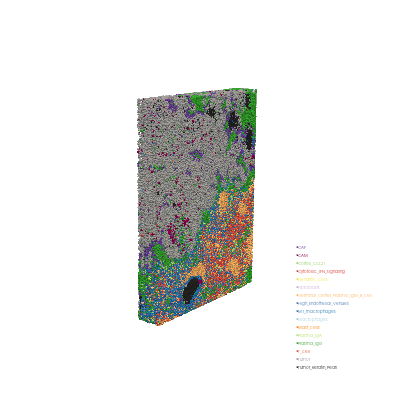

CameraPosition(position=(3463.5171334479587, 23927.044977244626, -16208.928424517384),
               focal_point=(10000.0, 2000.0, 550.7246417999268),
               viewup=(-0.9730153758368119, -0.17606927302684708, 0.14913312670545562))

In [ ]:
three_d_plot(
        model=pc_model,
        key="pred_label",
        model_size=2,
        model_style="points",
        opacity=1,
        background="white",
        cpo=saved_oblique_view,
        window_size=(400, 400),
        jupyter="static",
        legend_size=(0.22, 0.35) # adjust the legend size
    )

In [6]:
### tumor region
adata_tumor = adata[adata.obs["pred_label"] == "Tumor"].copy()
pc_model, plot_cmap = construct_pc(
    adata=adata_tumor.copy(),
    spatial_key="spatial",
    groupby="pred_label",
    key_added="pred_label",
    colormap=anno_colors
)

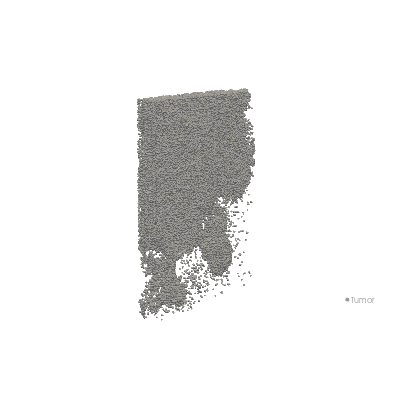

CameraPosition(position=(3463.5171334479587, 23927.044977244626, -16208.928424517384),
               focal_point=(10000.0, 2000.0, 550.7246417999268),
               viewup=(-0.9730153758368119, -0.17606927302684708, 0.14913312670545562))

In [50]:
three_d_plot(
        model=pc_model,
        key="pred_label",
        model_size=2,
        model_style="points",
        opacity=1,
        background="white",
        cpo=saved_oblique_view,
        window_size=(400, 400),
        jupyter="static",
    )

### voxelize tumor region

In [7]:
grid = points_to_imagedata(
    pc_model,
    grid_shape=(532, 400, 34),
    x_range=(6000, 14000),
    y_range=(-1000, 5000),
    z_range=(57.97, 1043.48),
    label_to_value={"pred_label": {"Tumor": 1}},
    empty_voxel_value=0,
)

In [9]:
grid.save("/Users/shuilan/Library/CloudStorage/OneDrive-InsideMDAnderson/3D spatial transcriptomics/data/3D/tumor_mask.vti")

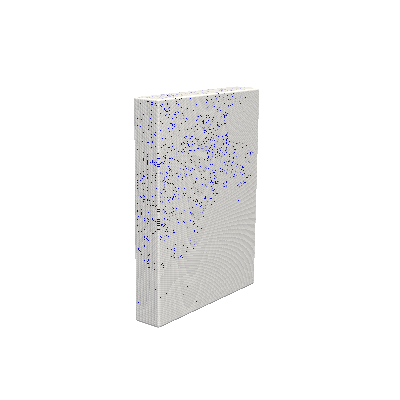

CameraPosition(position=(3463.5171334479587, 23927.044977244626, -16208.928424517384),
               focal_point=(10000.0, 2000.0, 550.7246417999268),
               viewup=(-0.9730153758368119, -0.17606927302684708, 0.14913312670545562))

In [10]:
## the point cloud is very sparse
three_d_plot(
    model=grid,
    key="pred_label",
    colormap=["white", "blue"],   # 0 - white, 1 - blue
    model_size=4,
    model_style="points",
    opacity=1,
    background="white",
    cpo=saved_oblique_view,
    window_size=(400, 400),
    jupyter="static",
    show_legend = False
)

Visualize the voxel data in paraview is recommended. Please see **Paraview Visualization** at https://unist-tutorial.readthedocs.io/en/latest/tutorial.html.

In [8]:
print("Dimensions:", grid.GetDimensions())
print("Spacing:", grid.GetSpacing())  ## note that the dispersity in z direction is larger than x and y
print("Origin:", grid.GetOrigin())
print("Extent:", grid.GetExtent())
print("Scalar Type:", grid.GetScalarTypeAsString())
print("Scalar Range:", grid.GetScalarRange())

Dimensions: (533, 401, 35)
Spacing: (15.037593984962406, 15.0, 28.985588235294117)
Origin: (6000.0, -1000.0, 57.97)
Extent: (0, 532, 0, 400, 0, 34)
Scalar Type: double
Scalar Range: (0.0, 1.0)


#### downsampling along x,y

In [9]:
import vtk
resampler = vtk.vtkImageResample()
resampler.SetInputData(grid)

factor = 0.5
resampler.SetAxisMagnificationFactor(0, factor)  
resampler.SetAxisMagnificationFactor(1, factor)  
resampler.SetAxisMagnificationFactor(2, 1)  

resampler.Update()
downsampled_data = resampler.GetOutput()

print(f"Dimensions after downsampling: {downsampled_data.GetDimensions()}")
print(f"Spacing after downsampling: {downsampled_data.GetSpacing()}")

Dimensions after downsampling: (267, 201, 35)
Spacing after downsampling: (30.075187969924812, 30.0, 28.985588235294117)


### morphologiy closing

In [10]:
from unist.downstream.morph import closing, opening, dilation, erosion

In [11]:
grid.set_active_scalars("pred_label")

(<FieldAssociation.CELL: 1>, pyvista_ndarray([0., 0., 0., ..., 0., 0., 0.]))

In [12]:
grid_closed = closing(
    grid,
    foreground_value=1,
    background_value=0,
    kernel_size=(10, 10, 20),
)

In [14]:
grid_closed.save("/Users/shuilan/Library/CloudStorage/OneDrive-InsideMDAnderson/3D spatial transcriptomics/data/3D/tumor_mask_closed.vti")

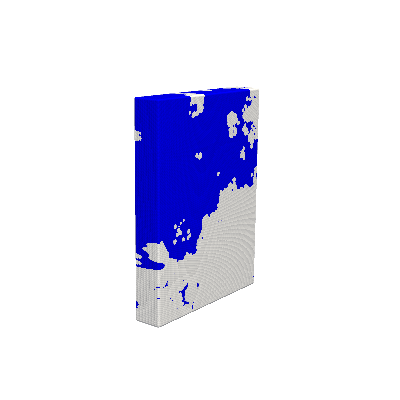

CameraPosition(position=(3463.5171334479587, 23927.044977244626, -16208.928424517384),
               focal_point=(10000.0, 2000.0, 550.7246417999268),
               viewup=(-0.9730153758368119, -0.17606927302684708, 0.14913312670545562))

In [17]:
three_d_plot(
    model=grid_closed,
    key="pred_label",
    colormap=["white", "blue"],   # 0 - white, 1 - blue
    model_size=4,
    model_style="points",
    opacity=1,
    background="white",
    cpo=saved_oblique_view,
    window_size=(400, 400),
    jupyter="static",
    show_legend = False
)

### morphology dilate to get peritumoral region

In [ ]:
from unist.downstream.morph import periphery_mask, boundary_mask

periphery = periphery_mask(
    grid_closed,
    foreground_value=1,
    background_value=0,
    kernel_size=(5, 5, 3), # adjust the kernel size to control the thickness of the periphery mask
    output_value=2, # set periphery voxels to 2 for better visualization in paraview
)

periphery.save("/Users/shuilan/Library/CloudStorage/OneDrive-InsideMDAnderson/3D spatial transcriptomics/data/3D/periphery_mask.vti")

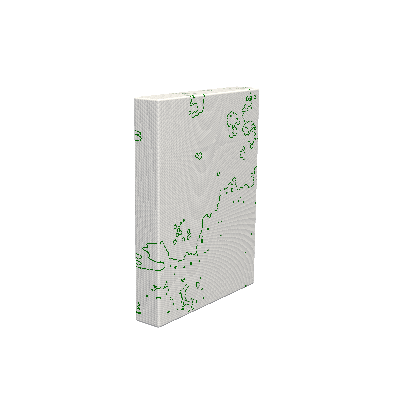

CameraPosition(position=(3463.5171334479587, 23927.044977244626, -16208.928424517384),
               focal_point=(10000.0, 2000.0, 550.7246417999268),
               viewup=(-0.9730153758368119, -0.17606927302684708, 0.14913312670545562))

In [15]:
three_d_plot(
    model=periphery,
    key="pred_label",
    colormap=["white", "green"],   # 0 - white, 2 - green
    model_size=4,
    model_style="points",
    opacity=1,
    background="white",
    cpo=saved_oblique_view,
    window_size=(400, 400),
    jupyter="static",
    show_legend = False
)

### morphology erode to get tumor boundary

In [16]:
boundary = boundary_mask(
    grid_closed,
    foreground_value=1,
    background_value=0,
    kernel_size=(3, 3, 3),
    output_value=3,
)
boundary.save("/Users/shuilan/Library/CloudStorage/OneDrive-InsideMDAnderson/3D spatial transcriptomics/data/3D/boundary_mask.vti")

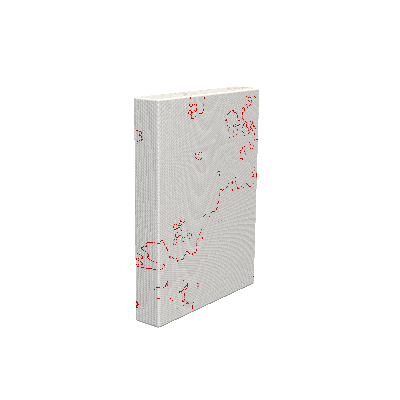

CameraPosition(position=(3463.5171334479587, 23927.044977244626, -16208.928424517384),
               focal_point=(10000.0, 2000.0, 550.7246417999268),
               viewup=(-0.9730153758368119, -0.17606927302684708, 0.14913312670545562))

In [17]:
three_d_plot(
    model=boundary,
    key="pred_label",
    colormap=["white", "red"],   # 0 - white, 3 - red
    model_size=4,
    model_style="points",
    opacity=1,
    background="white",
    cpo=saved_oblique_view,
    window_size=(400, 400),
    jupyter="static",
    show_legend = False
)

### morphology characteristic

In [ ]:
from unist.downstream.morph import calculate_volume_and_surface_area
vol, area = calculate_volume_and_surface_area(grid_closed, foreground_value=1) 

## the unit is in voxel, to convert to physical unit, we need to multiply by the voxel spacing

voxel_volume = grid_closed.GetSpacing()[0] * grid_closed.GetSpacing()[1] * grid_closed.GetSpacing()[2]
physical_volume = vol * voxel_volume
print(f"Volume in voxels: {vol}, Volume in physical units: {physical_volume}")  

voxel_area = 2 * (grid_closed.GetSpacing()[0] * grid_closed.GetSpacing()[1] +
                      grid_closed.GetSpacing()[1] * grid_closed.GetSpacing()[2] +
                      grid_closed.GetSpacing()[0] * grid_closed.GetSpacing()[2])
physical_area = area * voxel_area
print(f"Surface area in voxels: {area}, Surface area in physical units: {physical_area}")

### mesh reconstruction

In [14]:
contour_filter = vtk.vtkContourFilter()
contour_filter.SetInputData(grid_closed) 
contour_filter.SetValue(0, 0.5)  ## isosurface at 0.5 to separate foreground (1) and background (0)
contour_filter.ComputeNormalsOn()
contour_filter.Update()

raw_mesh = contour_filter.GetOutput()
print(f" -> The raw mesh contains {raw_mesh.GetNumberOfPolys()} triangular faces.")

smoother = vtk.vtkSmoothPolyDataFilter()
smoother.SetInputData(raw_mesh)
smoother.SetNumberOfIterations(20)
smoother.SetRelaxationFactor(0.1)
smoother.FeatureEdgeSmoothingOff()
smoother.BoundarySmoothingOn()
smoother.Update()

# Get the smoothed mesh
smoothed_mesh = smoother.GetOutput()
print(f" -> The smoothed mesh contains {smoothed_mesh.GetNumberOfPolys()} triangular faces.")

decimator = vtk.vtkQuadricDecimation()
decimator.SetInputData(smoothed_mesh)

# Set target reduction ratio (e.g., 0.9 means reducing to 10% of the original number of triangles)
decimator.SetTargetReduction(0.9)
decimator.Update()

# Get the final lightweight mesh
final_mesh = decimator.GetOutput()
print(f" -> The final mesh contains {final_mesh.GetNumberOfPolys()} triangular faces.")

# --- 4. Save the final mesh ---
final_stl_path = "/Users/shuilan/Library/CloudStorage/OneDrive-InsideMDAnderson/3D spatial transcriptomics/data/3D/final_tumor_mesh.stl"
stl_writer = vtk.vtkSTLWriter()
stl_writer.SetFileName(final_stl_path)
stl_writer.SetInputData(final_mesh)
stl_writer.Write()

print("----------------------------------------")
print(f"Pipeline complete! The final mesh has been saved as: {final_stl_path}")

 -> The raw mesh contains 527986 triangular faces.
 -> The smoothed mesh contains 527986 triangular faces.
 -> The final mesh contains 52797 triangular faces.
----------------------------------------
Pipeline complete! The final mesh has been saved as: /Users/shuilan/Library/CloudStorage/OneDrive-InsideMDAnderson/3D spatial transcriptomics/data/3D/final_tumor_mesh.stl
